In [1]:
# Step 1 - Load Data 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import sys 
sys.path.append("/home/ishanya-poddar/Desktop/Projects/ML + NLP/ML&NLP/src")

df = pd.read_csv("/home/ishanya-poddar/Desktop/Projects/ML + NLP/ML&NLP/Datasets/Processed Datasets/cleaned_data.csv")

In [2]:
# Step 2 - Create a Customer Level Aggregation
customer_df = df.groupby("customer_unique_id").agg({
    "order_id" : "nunique", 
    "order_total_price" : "sum", 
    "review_score" : "mean"
}).reset_index()

customer_df.columns = [
    "customer_unique_id", 
    "num_orders", 
    "total_spent", 
    "avg_review_score"
]

# We will fill NaN avg_review_score (The customers who never left a review) with the median 
customer_df["avg_review_score"] = customer_df["avg_review_score"].fillna(customer_df["avg_review_score"].median())

# We will drop any remaining NaN rows just in case 
customer_df.dropna(inplace = True)
customer_df.reset_index(drop = True, inplace = True)

customer_df.head()

,customer_unique_id,num_orders,total_spent,avg_review_score
0,0000366f3b9a7992bf8c76cfdf3221e2,1,129.90,5.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90,4.0
2,0000f46a3911fa3c0805444483337064,1,69.00,3.0
3,0000f6ccb0745a6a4b88665a16c9f078,1,25.99,4.0
4,0004aac84e0df4da2b147fca70cf8255,1,180.00,5.0


In [3]:
# Step 3 - Perform Feature Scaling 
from sklearn.preprocessing import StandardScaler 

scaler = StandardScaler()
scaled_features = scaler.fit_transform(
    customer_df[["num_orders", "total_spent", "avg_review_score"]]
)

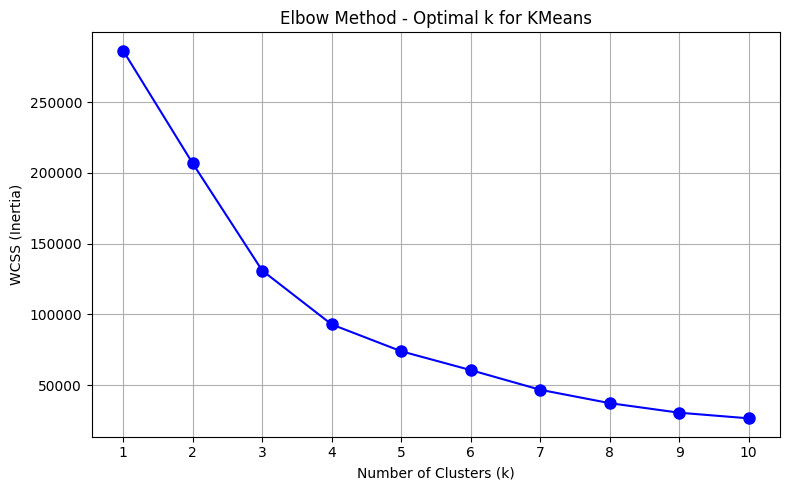

WCSS values for each k:
  k=1: 286260.00
  k=2: 206654.81
  k=3: 130906.76
  k=4: 92812.97
  k=5: 73857.46
  k=6: 60532.91
  k=7: 46636.41
  k=8: 37179.87
  k=9: 30422.70
  k=10: 26441.84


In [5]:
# Feedback Implementation - Perform Elbow Method To Find Optimal K
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []
K_RANGE = range(1, 11)

for k in K_RANGE:
    kmeans_elbow = KMeans(n_clusters= k, random_state = 42, n_init = 10)
    kmeans_elbow.fit(scaled_features)
    wcss.append(kmeans_elbow.inertia_)

plt.figure(figsize = (8, 5))
plt.plot(list(K_RANGE), wcss, 'bo-', markersize = 8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method - Optimal k for KMeans')
plt.xticks(list(K_RANGE))
plt.grid(True)
plt.tight_layout()
plt.show()

print('WCSS values for each k:')
for k, w in zip(K_RANGE, wcss):
    print(f'  k={k}: {w:.2f}')

In [ ]:
# Step 4 - Perform KMeans Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters = 4, random_state = 42)
customer_df["cluster"] = kmeans.fit_predict(scaled_features)

# We will use sample_size parameter to speed up silhouette computation on large datasets
SILHOUETTE_SAMPLE_SIZE = 5000
sil_score = silhouette_score(
    scaled_features,
    customer_df["cluster"],
    sample_size = min(SILHOUETTE_SAMPLE_SIZE, len(customer_df)),
    random_state = 42
)
print("Silhouette Score (sampled) : ", sil_score)

Silhouette Score (sampled) :  0.6994537666449524


In [ ]:
# Feedback Implementation - Apply Cluster Validation Metrics
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt

# Internal Metrics
dbi = davies_bouldin_score(scaled_features, customer_df["cluster"])
chi = calinski_harabasz_score(scaled_features, customer_df["cluster"])

print("=== KMeans Cluster Validation ===")
print(f"  Silhouette Score      : {sil_score:.4f}  (higher is better, best=1)")
print(f"  Davies-Bouldin Index  : {dbi:.4f}  (lower is better, best=0)")
print(f"  Calinski-Harabasz     : {chi:.2f}  (higher is better)")

# Cluster Profiles - What does each cluster represent?
profile = customer_df.groupby("cluster")[["num_orders", "total_spent", "avg_review_score"]].mean()
sizes   = customer_df["cluster"].value_counts().sort_index().rename("size")
print("\n=== Cluster Profiles ===")
print(profile.join(sizes).round(2))

# Visualize profiles
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features = ["num_orders", "total_spent", "avg_review_score"]
colors   = ["steelblue", "coral", "mediumseagreen", "mediumpurple"]

for i, feat in enumerate(features):
    axes[i].bar(profile.index.astype(str), profile[feat],
                color=colors[:len(profile)], edgecolor='white')
    axes[i].set_title(f'Mean {feat} per Cluster')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel(feat)

plt.suptitle('Cluster Profile Comparison', fontsize=13)
plt.tight_layout()
plt.show()

# Cluster Size Distribution
cluster_sizes = customer_df["cluster"].value_counts().sort_index()
total = len(customer_df)
print("\n=== Cluster Size Distribution ===")
for c, n in cluster_sizes.items():
    print(f"  Cluster {c}: {n:>6} customers  ({n/total*100:.1f}%)")

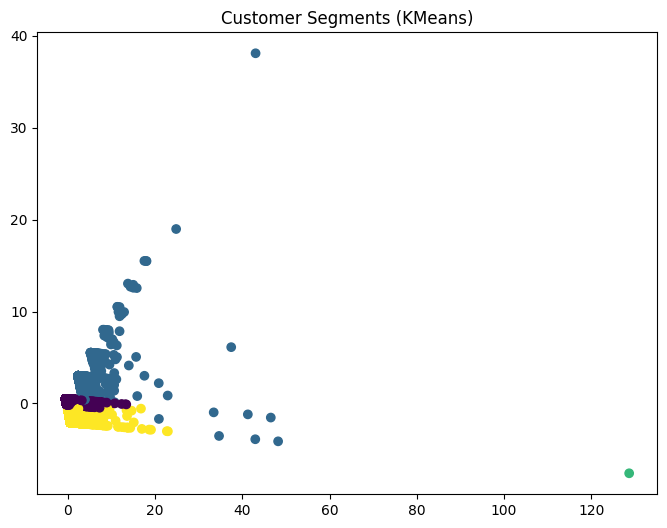

In [ ]:
# Step 5 - Perform PCA Visualization 
from sklearn.decomposition import PCA 

pca = PCA(n_components = 2)
pca_features = pca.fit_transform(scaled_features)

plt.figure(figsize = (8, 6))
plt.scatter(pca_features[:, 0], pca_features[:, 1], c = customer_df["cluster"], cmap = "viridis")
plt.title("Customer Segments (KMeans)")
plt.show()

In [ ]:
# Step 6 - Perform DBSCAN 
from sklearn.cluster import DBSCAN 

# We will sample a subset for faster evaluation as we can adjust DBSCAN_SAMPLE_SIZE as needed
DBSCAN_SAMPLE_SIZE = 5000

sample_df = customer_df.sample(n = min(DBSCAN_SAMPLE_SIZE, len(customer_df)), random_state = 42).copy()
sample_features = scaled_features[sample_df.index]

dbscan = DBSCAN(eps = 0.5, min_samples = 10)
sample_df["dbscan_cluster"] = dbscan.fit_predict(sample_features)

# We will check Silhouette score as we exclude noise points which are labeled as -1
mask = sample_df["dbscan_cluster"] != -1
if mask.sum() > 1:
    score = silhouette_score(sample_features[mask], sample_df.loc[mask, "dbscan_cluster"])
    print(f"The Silhouette Score On Sample (Excluding Noise) : {score : .4f}")
else: 
    print("There are too many Noise Points - We need to try adjusting eps or min_samples")    

The Silhouette Score On Sample (Excluding Noise) :  0.6654
